In [1]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
pd.DataFrame.iteritems = pd.DataFrame.items
from random import gauss as rgauss
import numpy as np
from scipy.stats.mstats import gmean

from tqdm.notebook import tqdm

import pingouin as pg

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

/Users/roberto/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
def mgauss(mu=1, sigma=.1, threshold=2):
    """This limits the generated values within ± <threshold> standard deviations
    """
    
    val = mu + sigma * threshold * 2

    while abs(val - mu) > sigma * threshold: 
        val = rgauss(mu, sigma)

    return val

In [3]:
### Overall survival/simulation 1
# params
# ======

survival_std = 0.28        # % standard deviation of survival

survival_high = 40         # survival of untreated GBMsema6a-high 
survival_high_tmz = 110    # survival of TMZ-treated GBMsema6a-high (+175% vs untreated)
survival_low = 60          # survival of untreated GBMsema6a-low (+30% vs SEMA6Ahigh)
survival_low_tmz = 165     # survival of TMZ-treated GBMsema6a-low (+175% vs untreated)

#n = 6 # numerosity per experimental group

In [4]:
#plot an example of distribution
high     = [mgauss(mu=survival_high,     sigma=survival_std * survival_high,     threshold=3) for _ in range(n)]
high_tmz = [mgauss(mu=survival_high_tmz, sigma=survival_std * survival_high_tmz, threshold=3) for _ in range(n)]
low      = [mgauss(mu=survival_low,      sigma=survival_std * survival_low,      threshold=3) for _ in range(n)]
low_tmz  = [mgauss(mu=survival_low_tmz,  sigma=survival_std * survival_low_tmz,  threshold=3) for _ in range(n)]

repack = {"high": high, "high_tmz": high_tmz, "low": low, "low_tmz": low_tmz}
repack = pd.DataFrame(repack, index=range(n))

plt.figure(figsize=(2,3))
sns.barplot(data=repack)
sns.swarmplot(data=repack, s=10, linewidth=1, alpha=.7)

NameError: name 'n' is not defined

In [62]:
n_values = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
t_power = []
a_power = []

#compute p-values for ttest and Dunnett post-hoc test over 1000 simulations
for n in n_values:
    t_pvals = []
    a_pvals = []   
 

    n_sims = 1000
    for i in tqdm(range(n_sims)):
        high     = [mgauss(mu=survival_high,     sigma=survival_std * survival_high,     threshold=3) for _ in range(n)]
        high_tmz = [mgauss(mu=survival_high_tmz, sigma=survival_std * survival_high_tmz, threshold=3) for _ in range(n)]
        low      = [mgauss(mu=survival_low,      sigma=survival_std * survival_low,      threshold=3) for _ in range(n)]
        low_tmz  = [mgauss(mu=survival_low_tmz,  sigma=survival_std * survival_low_tmz,  threshold=3) for _ in range(n)]
    
        t_res = pg.ttest(high, low)
        t_pval = t_res["p-val"].iloc[0]
        t_pvals.append(t_pval)

        repacked_vals = high + high_tmz + low + low_tmz
        repacked_hues = ["high" for _ in range(n)] + ["high_tmz" for _ in range(n)] + ["low" for _ in range(n)] + ["low_tmz" for _ in range(n)]
        repack = {"vals": repacked_vals, "tags": repacked_hues}
        repack = pd.DataFrame(repack, index=range(n * 4))
        #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
        posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
        a_pval = posthoc[(posthoc["A"] == "high_tmz") &  (posthoc["B"] == "low_tmz")]["p-corr"].iloc[0]
        a_pvals.append(a_pval)
        
        
    t = np.array(t_pvals)
    a = np.array(a_pvals)
    t_pow = sum(t < .05)
    a_pow = sum(a < .05)
    
    t_power.append(t_pow)
    a_power.append(a_pow)
    print(f"For n = {n} the power of ttest is {sum(t < .05)/10}%")
    print(f"For n = {n} the power of Dunnet post-hoc test is {sum(a < .05)/10}%")
    
        

  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 4 the power of ttest is 37.8%
For n = 4 the power of Dunnet post-hoc test is 37.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 5 the power of ttest is 48.9%
For n = 5 the power of Dunnet post-hoc test is 46.4%


  0%|          | 0/1000 [00:00<?, ?it/s]

...

For n = 13 the power of ttest is 93.7%
For n = 13 the power of Dunnet post-hoc test is 94.1%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 14 the power of ttest is 95.6%
For n = 14 the power of Dunnet post-hoc test is 93.8%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 15 the power of ttest is 95.4%
For n = 15 the power of Dunnet post-hoc test is 96.5%


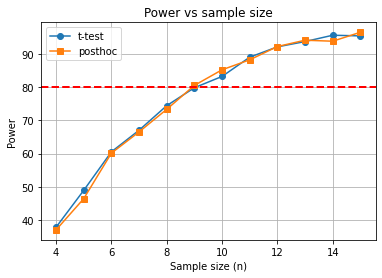

In [69]:
plt.figure()

plt.plot(n_values, np.array(t_power)/10, marker='o', label='t-test')
plt.plot(n_values, np.array(a_power)/10, marker='s', label='posthoc')

plt.xlabel('Sample size (n)')
plt.ylabel('Power')
plt.title('Power vs sample size')


threshold = 80
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

plt.legend()
plt.grid(True)

plt.show()



In [64]:
a_power

[370, 464, 601, 665, 733, 805, 852, 882, 922, 941, 938, 965]

In [8]:
t_pvals = []
a_pvals = []

gene_std = .3 # standard deviation of the gene expression

gene_saline = 1
gene_ntc = 1
gene_sirna = .2
n = 5 # numerosity per experimental group

n_sims = 10_000
for i in tqdm(range(n_sims)):
    saline = [mgauss(mu=gene_saline, sigma=gene_std * gene_saline, threshold=3) for _ in range(n)]
    ntc    = [mgauss(mu=gene_ntc,    sigma=gene_std * gene_ntc,    threshold=3) for _ in range(n)]
    sirna  = [mgauss(mu=gene_sirna,  sigma=gene_std * gene_sirna,  threshold=3) for _ in range(n)]

    t_res = pg.ttest(saline, sirna)
    t_pval = t_res["p_val"].iloc[0]
    t_pvals.append(t_pval)

    repacked_vals = saline + ntc + sirna
    repacked_hues = ["saline" for _ in range(n)] + ["ntc" for _ in range(n)] + ["sirna" for _ in range(n)]
    repack = {"vals": repacked_vals, "tags": repacked_hues}
    repack = pd.DataFrame(repack, index=range(n * 3))
    #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
    posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
    a_pval = posthoc[(posthoc["A"] == "saline") &  (posthoc["B"] == "sirna")]["p_corr"].iloc[0]
    a_pvals.append(a_pval)

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyError: 'p_val'

In [ ]:
t = np.array(t_pvals)
a = np.array(a_pvals)
print(f"The power of ttest is {sum(t < .05)}%")
print(f"The power of Dunnet post-hoc test is {sum(a < .05)}%")

In [ ]:
t_pvals = []
a_pvals = []

gene_std = .4 # standard deviation of the gene expression

gene_saline = 1
gene_ntc = 1
gene_sirna = .2
n = 5 # numerosity per experimental group

n_sims = 10_000
for i in tqdm(range(n_sims)):
    saline = [mgauss(mu=gene_saline, sigma=gene_std * gene_saline, threshold=3) for _ in range(n)]
    ntc    = [mgauss(mu=gene_ntc,    sigma=gene_std * gene_ntc,    threshold=3) for _ in range(n)]
    sirna  = [mgauss(mu=gene_sirna,  sigma=gene_std * gene_sirna,  threshold=3) for _ in range(n)]

    t_res = pg.ttest(saline, sirna)
    t_pval = t_res["p_val"].iloc[0]
    t_pvals.append(t_pval)

    repacked_vals = saline + ntc + sirna
    repacked_hues = ["saline" for _ in range(n)] + ["ntc" for _ in range(n)] + ["sirna" for _ in range(n)]
    repack = {"vals": repacked_vals, "tags": repacked_hues}
    repack = pd.DataFrame(repack, index=range(n * 3))
    #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
    posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
    a_pval = posthoc[(posthoc["A"] == "saline") &  (posthoc["B"] == "sirna")]["p_corr"].iloc[0]
    a_pvals.append(a_pval)

In [ ]:
t = np.array(t_pvals)
a = np.array(a_pvals)

In [ ]:
sum(t < .05)

In [ ]:
sum(a < .05)